In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read Data/Preprocessing

In [2]:
raw_tsa_data = pd.read_csv("../data/tsa-throughput-data-complete.csv", parse_dates=["DateTime"])

In [3]:
# Rename columns to snake case
raw_tsa_data.columns = (
    raw_tsa_data.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
)

In [4]:
# Sum over checkpoint data
tsa_airport_data = (
    raw_tsa_data.groupby(["datetime", "airport_code"], as_index=False)
      .agg({
          "airport_name": "first",
          "city": "first",
          "state": "first",
          "total_passenger_throughput": "sum"
      })
)

In [8]:
# Select Chicago airport data
ord_data = tsa_airport_data[tsa_airport_data['airport_code'] == 'ORD'].reset_index(drop=True)

In [9]:
# Test/Train split: obtain training set for Chicago airport
ord_train = ord_data[ord_data['datetime'] < "2025-01-01"]

In [10]:
# Extract hourly, daily, weekly, and monthly TSA throughput data for training
ord_hourly_tr = ord_train[['datetime', 'total_passenger_throughput']].set_index('datetime').asfreq("h")
ord_daily_tr = ord_hourly_tr.resample("D")["total_passenger_throughput"].sum().asfreq("D").drop("2024-02-29")
ord_weekly_tr = ord_hourly_tr.resample("W", label="left")["total_passenger_throughput"].sum().iloc[1:-1].asfreq("W")
ord_monthly_tr = ord_hourly_tr.resample("MS")["total_passenger_throughput"].sum().asfreq("MS")

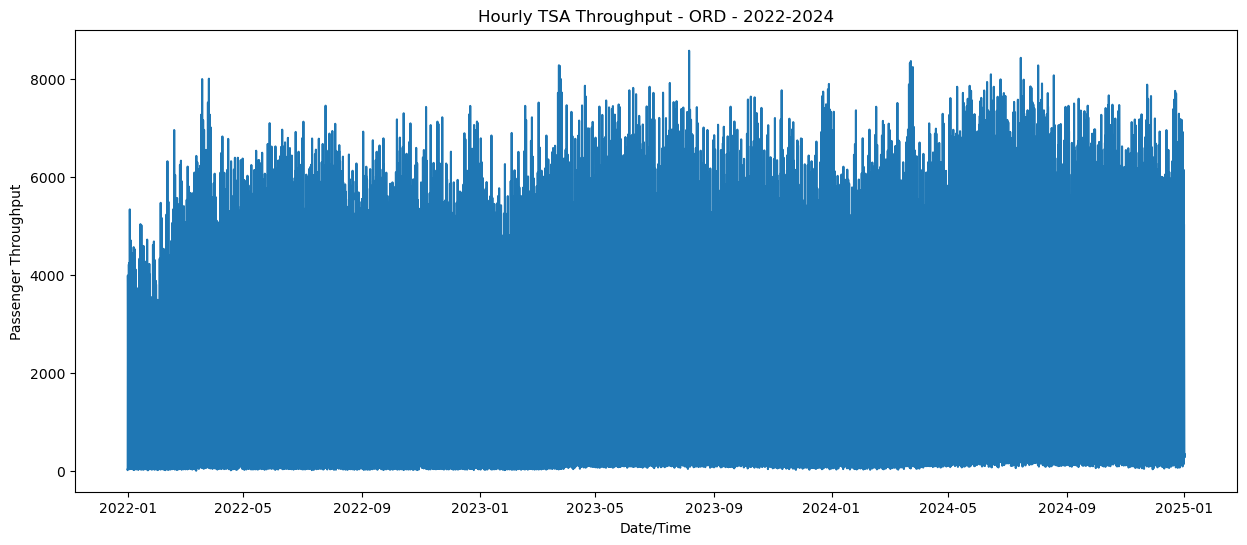

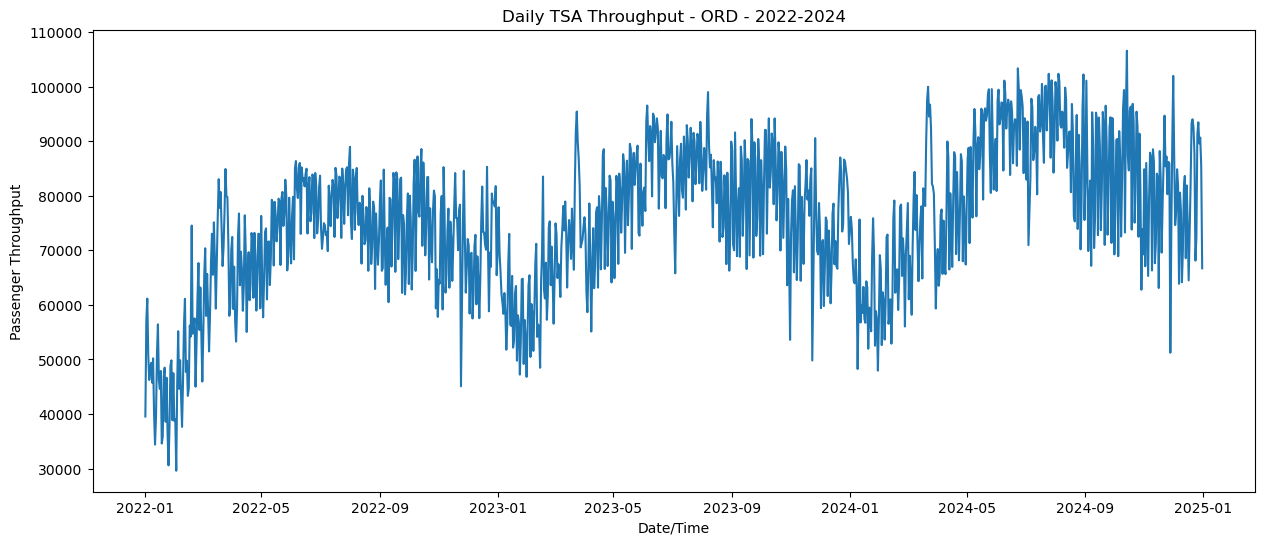

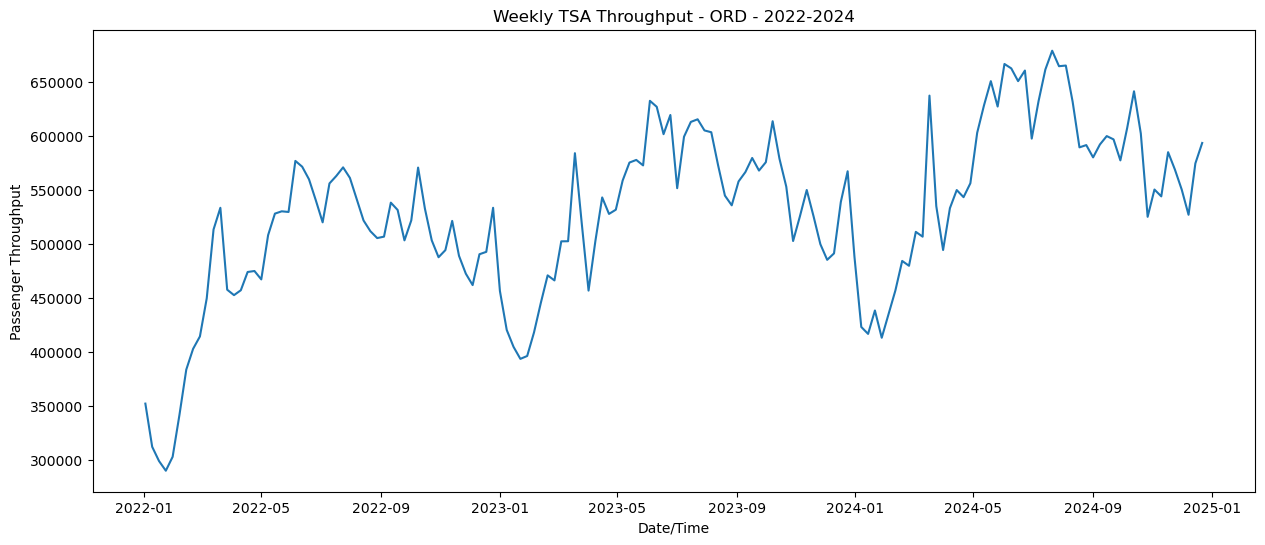

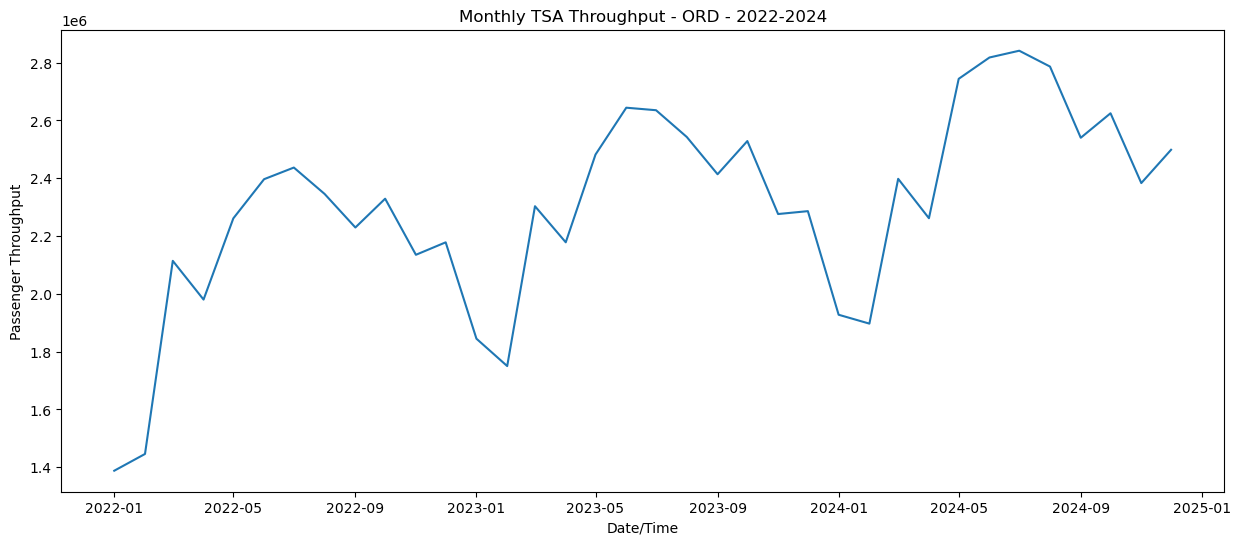

In [11]:
# Plot each dataset
plt.figure(figsize=(15, 6))
plt.plot(ord_hourly_tr)
plt.title('Hourly TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(ord_daily_tr)
plt.title('Daily TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_tr)
plt.title('Weekly TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(ord_monthly_tr)
plt.title('Monthly TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.show()

In [12]:
## Train/test splits for model validation
# Daily
ord_daily_tt = ord_daily_tr[ord_daily_tr.index < "2024-01-01"]
ord_daily_val = ord_daily_tr[ord_daily_tr.index >= "2024-01-01"]
# Weekly
ord_weekly_tt = ord_weekly_tr[ord_weekly_tr.index < "2024-01-01"]
ord_weekly_val = ord_weekly_tr[ord_weekly_tr.index >= "2024-01-01"]
# Monthly
ord_monthly_tt = ord_monthly_tr[ord_monthly_tr.index < "2024-01-01"]
ord_monthly_val = ord_monthly_tr[ord_monthly_tr.index >= "2024-01-01"]

## Exponential Smoothing Model (Baseline)

### Daily Data

In [13]:
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_squared_error as mse

In [14]:
# Fit Holt-Winters exponential smoothing model (seasonal with trend) to daily TSA data
exps_model = ExponentialSmoothing(ord_daily_tt, trend='add', seasonal='add', seasonal_periods=365).fit()

/home/friedenberg/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [15]:
mse(ord_daily_val, exps_model.forecast(365)) / ord_daily_val.mean()

1248.727526701818

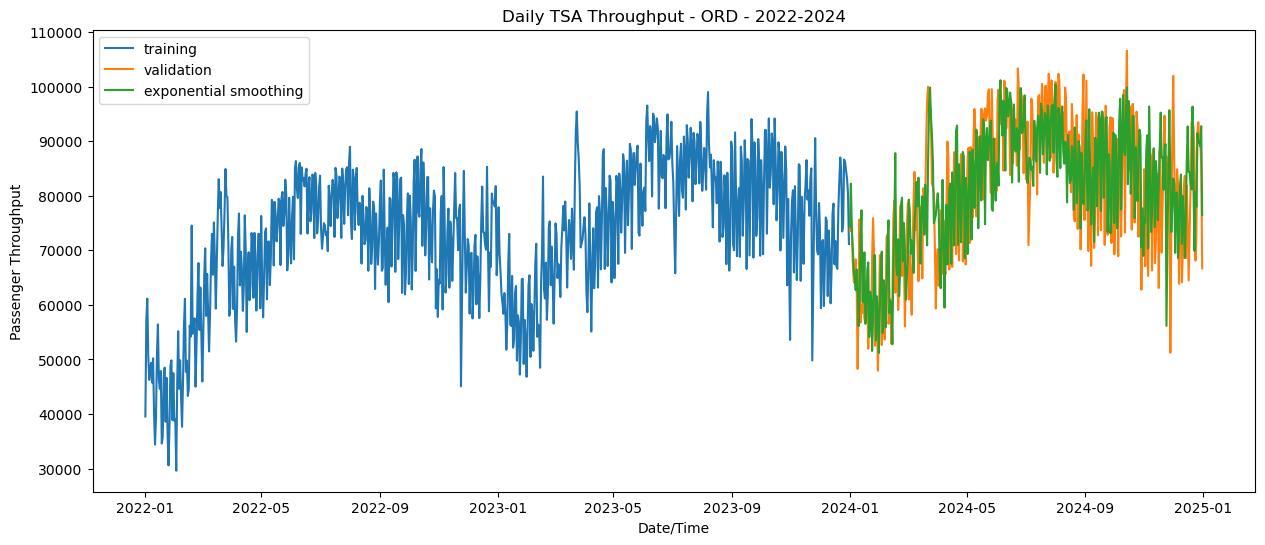

In [16]:
plt.figure(figsize=(15, 6))
plt.plot(ord_daily_tt, label='training')
plt.plot(ord_daily_val, label='validation')
plt.plot(ord_daily_val.index, exps_model.forecast(365), label='exponential smoothing')
plt.title('Daily TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

### Weekly Data

In [17]:
# Fit Holt-Winters exponential smoothing model (seasonal with trend) to daily TSA data
exps_model = ExponentialSmoothing(ord_weekly_tt, trend='add', seasonal='add', seasonal_periods=52).fit()

In [18]:
mse(ord_weekly_val, exps_model.forecast(51)) / ord_weekly_val.mean()

1250.3874078709416

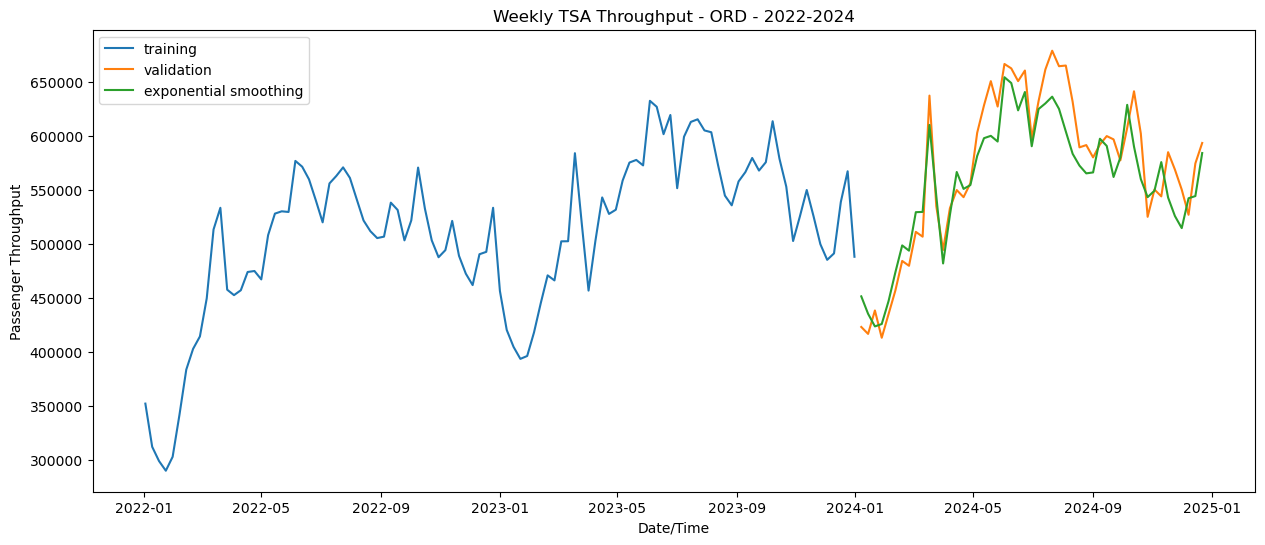

In [19]:
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_tt, label='training')
plt.plot(ord_weekly_val, label='validation')
plt.plot(ord_weekly_val.index, exps_model.forecast(51), label='exponential smoothing')
plt.title('Weekly TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

### Monthly Data

In [55]:
# Fit Holt-Winters exponential smoothing model (seasonal with trend) to monthly TSA data
exps_model = ExponentialSmoothing(ord_monthly_tt, trend='add', seasonal='add', seasonal_periods=12).fit()

In [57]:
mse(ord_monthly_val, exps_model.forecast(12)) / ord_monthly_val.mean()

4491.608578479191

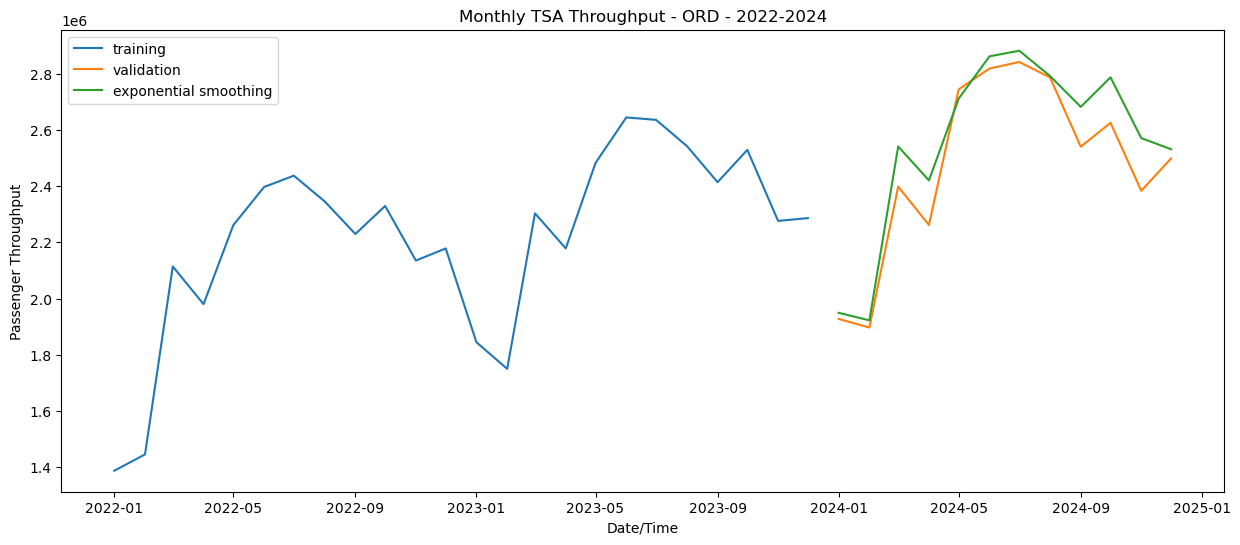

In [59]:
plt.figure(figsize=(15, 6))
plt.plot(ord_monthly_tt, label='training')
plt.plot(ord_monthly_val, label='validation')
plt.plot(ord_monthly_val.index, exps_model.forecast(12), label='exponential smoothing')
plt.title('Monthly TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

## Autocorrelation and Partial Autocorrelation

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

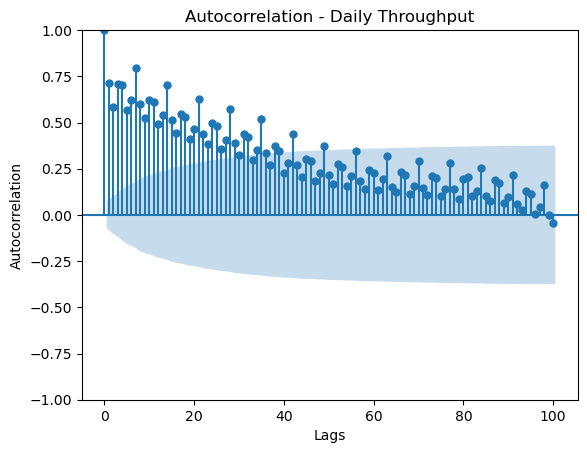

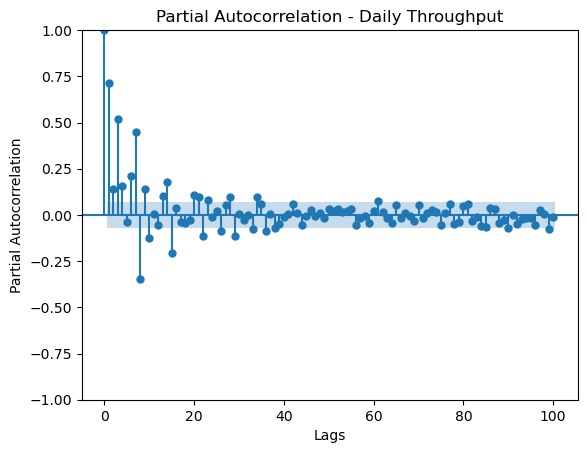

In [21]:
# Plot autocorrelation and partial autocorrelation for daily data
plot_acf(ord_daily_tt, lags=100)
plt.title("Autocorrelation - Daily Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()
plot_pacf(ord_daily_tt, lags=100)
plt.title("Partial Autocorrelation - Daily Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

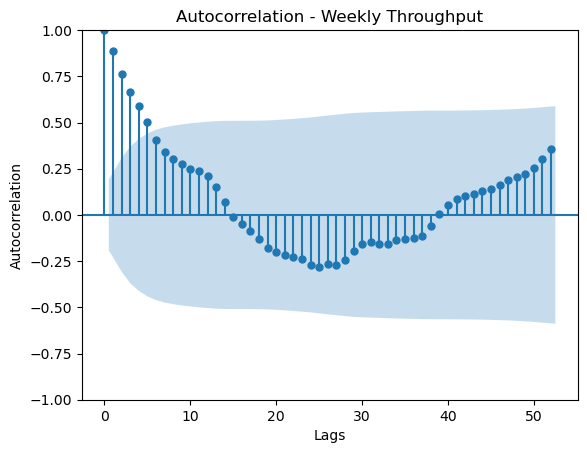

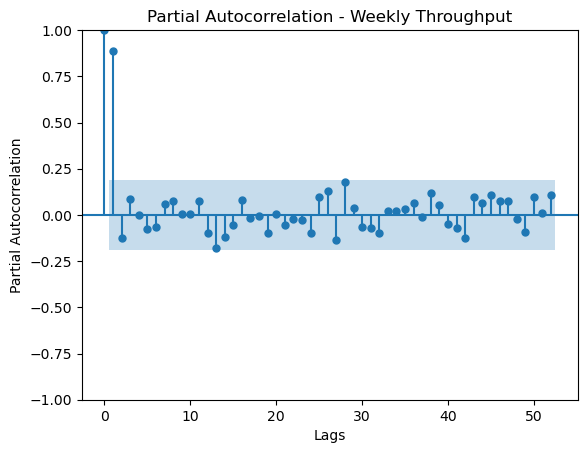

In [22]:
# Plot autocorrelation and partial autocorrelation for weekly data
plot_acf(ord_weekly_tt, lags=52)
plt.title("Autocorrelation - Weekly Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()
plot_pacf(ord_weekly_tt, lags=52)
plt.title("Partial Autocorrelation - Weekly Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

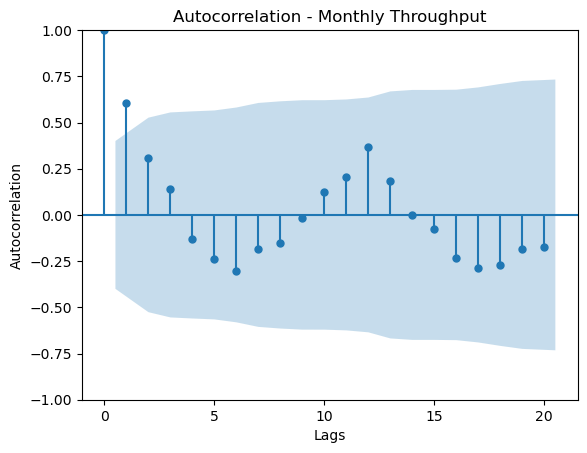

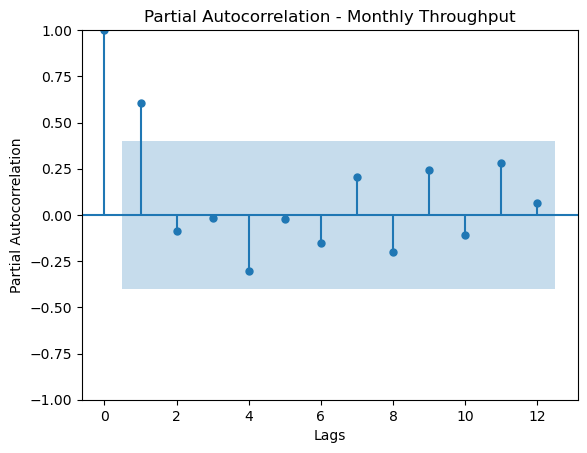

In [82]:
# Plot autocorrelation and partial autocorrelation for monthly data
plot_acf(ord_monthly_tt, lags=20)
plt.title("Autocorrelation - Monthly Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()
plot_pacf(ord_monthly_tt, lags=12)
plt.title("Partial Autocorrelation - Monthly Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

## SARIMA Model - Weekly Data

It looks like the weekly data has the simplest structure for fitting a SARIMA model. Before doing so, let's apply some differences and see how this affects the autocorrelation

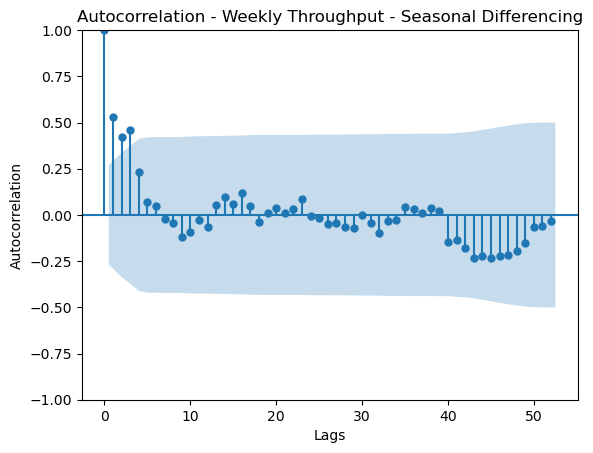

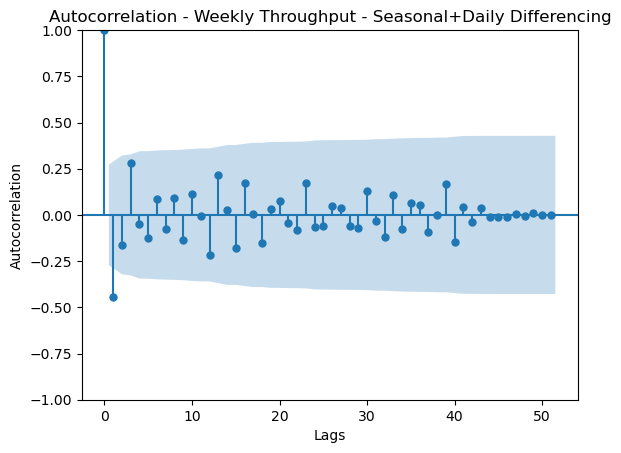

In [103]:
# Plot autocorrelation with seasonal differencing
plot_acf(ord_weekly_tt.diff(52)[52:], lags=52)
plt.title("Autocorrelation - Weekly Throughput - Seasonal Differencing")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

# Plot autocorrelation with seasonal differencing
plot_acf(ord_weekly_tt.diff(52).diff(1)[53:], lags=51)
plt.title("Autocorrelation - Weekly Throughput - Seasonal+Daily Differencing")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

This last plot looks pretty stationary! That means we likely want to use a SARIMA model with seasonality `s = 52` and differences `D = 1` and `d = 1`

Let's use `autoarima` to determine the `(p, q)` and `(P, Q)` parameters.

In [26]:
import pmdarima as pm

In [110]:
arima_model = pm.auto_arima(
    ord_weekly_tt,
    seasonal=True, m=52,
    d=0, D=1,
    start_p=0, max_p=1,
    start_q=0, max_q=1,
    start_P=0, max_P=1,
    start_Q=0, max_Q=1,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[52] intercept   : AIC=1225.036, Time=0.22 sec
 ARIMA(1,0,0)(1,1,0)[52] intercept   : AIC=1223.906, Time=14.57 sec
 ARIMA(0,0,1)(0,1,1)[52] intercept   : AIC=1220.611, Time=16.36 sec
 ARIMA(0,0,0)(0,1,0)[52]             : AIC=1312.593, Time=0.22 sec
 ARIMA(0,0,1)(0,1,0)[52] intercept   : AIC=1218.611, Time=0.85 sec
 ARIMA(0,0,1)(1,1,0)[52] intercept   : AIC=1220.607, Time=14.02 sec
 ARIMA(0,0,1)(1,1,1)[52] intercept   : AIC=inf, Time=39.45 sec
 ARIMA(1,0,1)(0,1,0)[52] intercept   : AIC=1199.741, Time=0.70 sec
 ARIMA(1,0,1)(1,1,0)[52] intercept   : AIC=1195.392, Time=32.77 sec
 ARIMA(1,0,1)(1,1,1)[52] intercept   : AIC=inf, Time=52.47 sec
 ARIMA(1,0,1)(0,1,1)[52] intercept   : AIC=1195.607, Time=28.15 sec
 ARIMA(0,0,0)(1,1,0)[52] intercept   : AIC=1226.695, Time=10.26 sec
 ARIMA(1,0,1)(1,1,0)[52]             : AIC=1194.015, Time=257.42 sec
 ARIMA(1,0,1)(0,1,0)[52]             : AIC=1201.605, Time=0.96 sec
 ARIMA(1,0,1)(1,1,1

In [111]:
arima_model_d1 = pm.auto_arima(
    ord_weekly_tt,
    seasonal=True, m=52,
    d=1, D=1,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=1, max_P=1,
    start_Q=0, max_Q=0,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,1,0)[52]             : AIC=1193.418, Time=27.65 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=1194.649, Time=0.42 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=1194.521, Time=44.31 sec
 ARIMA(0,1,1)(0,1,0)[52]             : AIC=1193.079, Time=0.26 sec
 ARIMA(0,1,1)(1,1,0)[52]             : AIC=1194.846, Time=47.42 sec
 ARIMA(1,1,1)(0,1,0)[52]             : AIC=1195.059, Time=0.76 sec
 ARIMA(0,1,2)(0,1,0)[52]             : AIC=1195.578, Time=0.37 sec
 ARIMA(1,1,0)(0,1,0)[52]             : AIC=1192.741, Time=0.32 sec
 ARIMA(2,1,0)(0,1,0)[52]             : AIC=1197.450, Time=0.33 sec
 ARIMA(2,1,1)(0,1,0)[52]             : AIC=1198.532, Time=1.01 sec
 ARIMA(1,1,0)(0,1,0)[52] intercept   : AIC=1194.325, Time=0.31 sec

Best model:  ARIMA(1,1,0)(0,1,0)[52]          
Total fit time: 123.197 seconds


Let's expand this last search to seasonal AR/MA

In [112]:
arima_model_d1 = pm.auto_arima(
    ord_weekly_tt,
    seasonal=True, m=52,
    d=1, D=1,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=1,
    start_Q=0, max_Q=1,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore"
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=1194.649, Time=0.61 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=1194.521, Time=42.55 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=1194.838, Time=67.79 sec
 ARIMA(1,1,0)(0,1,0)[52]             : AIC=1192.741, Time=0.15 sec
 ARIMA(1,1,0)(0,1,1)[52]             : AIC=1194.513, Time=52.13 sec
 ARIMA(1,1,0)(1,1,1)[52]             : AIC=inf, Time=335.28 sec
 ARIMA(2,1,0)(0,1,0)[52]             : AIC=1197.450, Time=0.33 sec
 ARIMA(1,1,1)(0,1,0)[52]             : AIC=1195.059, Time=0.92 sec
 ARIMA(0,1,1)(0,1,0)[52]             : AIC=1193.079, Time=0.48 sec
 ARIMA(2,1,1)(0,1,0)[52]             : AIC=1198.532, Time=1.06 sec
 ARIMA(1,1,0)(0,1,0)[52] intercept   : AIC=1194.325, Time=0.33 sec

Best model:  ARIMA(1,1,0)(0,1,0)[52]          
Total fit time: 501.643 seconds


Based on all these searches, it looks like the best fitting models are

`ARIMA(1,1,0)(0,1,0)[52]` and `ARIMA(1,0,1)(1,1,0)[52]`

Let's fit these models, calculate mse and compare with the baseline

In [128]:
sarima_model_1 = pm.ARIMA((1, 1, 0), (0, 1, 0, 52)).fit(ord_weekly_tt)
sarima_model_2 = pm.ARIMA((1, 0, 1), (1, 1, 0, 52)).fit(ord_weekly_tt)

In [129]:
print("ARIMA(1,1,0)(0,1,0)[52]: mse = ", mse(ord_weekly_val, sarima_model_1.predict(51)) / ord_weekly_val.mean())
print("ARIMA(1,0,1)(1,1,0)[52]: mse = ", mse(ord_weekly_val, sarima_model_2.predict(51)) / ord_weekly_val.mean())

ARIMA(1,1,0)(0,1,0)[52]: mse =  7917.326668463007
ARIMA(1,0,1)(1,1,0)[52]: mse =  2268.5907793817128


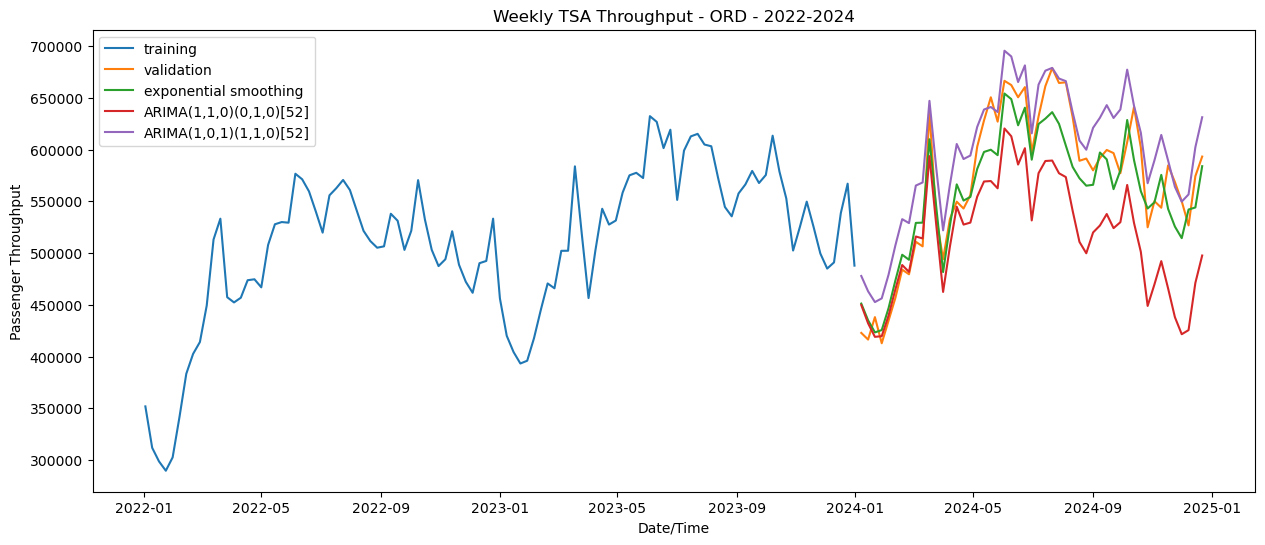

In [130]:
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_tt, label='training')
plt.plot(ord_weekly_val, label='validation')
plt.plot(ord_weekly_val.index, exps_model.forecast(51), label='exponential smoothing')
plt.plot(ord_weekly_val.index, sarima_model_1.predict(51), label='ARIMA(1,1,0)(0,1,0)[52]')
plt.plot(ord_weekly_val.index, sarima_model_2.predict(51), label='ARIMA(1,0,1)(1,1,0)[52]')
plt.title('Weekly TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

This is okay but still doesn't beat the baseline model. Let's see if we can do better

## ARIMA + Fourier Features

Seasonal ARIMA is the most ideal approach, but note that the training data here only has two seasons to train on. This may not be enough to properly fit a seasonal ARIMA.

Instead, another method we can try is to model the seasonality using Fourier features, and then feed this into a traditional ARIMA model without seasons.

In [193]:
# Create matrix of Fourier features for use in autoarima
def fourier_matrix(n, m=52, k=3, offset=0):
    t = np.arange(offset, offset + n, dtype=float)
    X = []
    for i in range(1, k + 1):
        X.append(np.sin(2*np.pi*i*t/m))
        X.append(np.cos(2*np.pi*i*t/m))
    return np.column_stack(X)

In [213]:
# Create Fourier features as exogenous data
k = 19
X_train = fourier_matrix(len(ord_weekly_tt), m=52, k=k, offset=0)

In [216]:
# Cross-validate ARIMA models + Fourier features
arima_model_fourier = pm.auto_arima(
    ord_weekly_tt,
    X=X_train,
    seasonal=False,
    max_d=1,
    trace=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2432.738, Time=0.86 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2390.408, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2409.741, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2414.329, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2769.105, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2425.473, Time=0.55 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 1.900 seconds


In [217]:
# build future exogenous Fourier features
X_future = fourier_matrix(51, m=52, k=k, offset=len(ord_weekly_tt))

In [218]:
print("ARIMA(0,1,0)(0,0,0)[0] + Fourier: mse = ", mse(ord_weekly_val, arima_model_fourier.predict(51, X=X_future)) / ord_weekly_val.mean())

ARIMA(0,1,0)(0,0,0)[0] + Fourier: mse =  1376.1874649571503


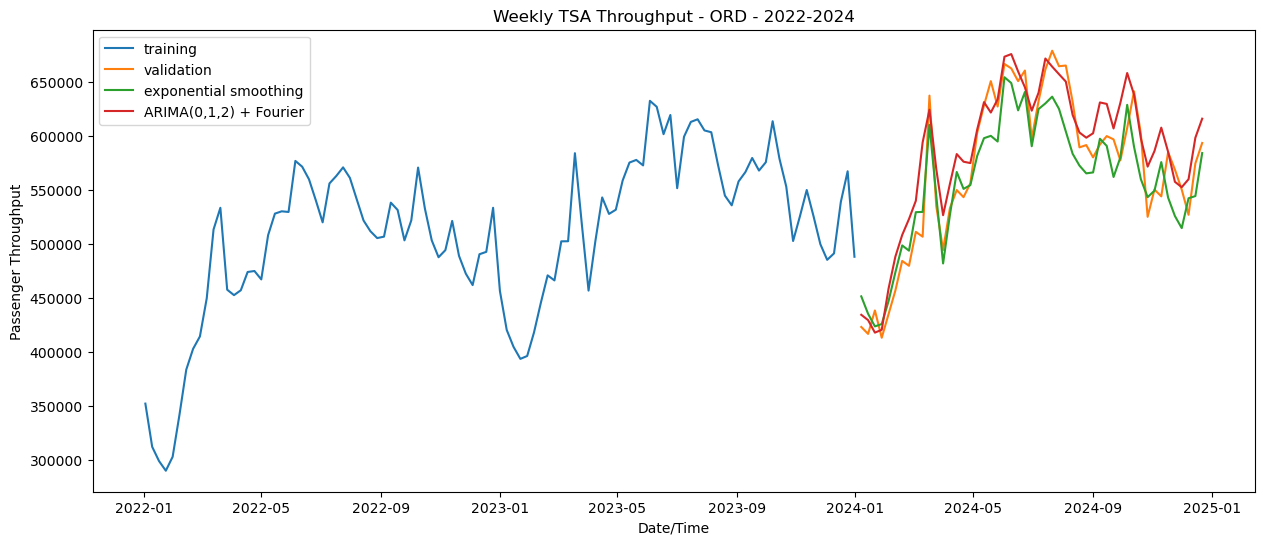

In [219]:
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_tt, label='training')
plt.plot(ord_weekly_val, label='validation')
plt.plot(ord_weekly_val.index, exps_model.forecast(51), label='exponential smoothing')
plt.plot(ord_weekly_val.index, arima_model_fourier.predict(51, X=X_future), label='ARIMA(0,1,2) + Fourier')
plt.title('Weekly TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

After testing a few values of `k`, it appears this gives the best results for `k=19`

Let's take a look at the autocorrelation of the residuals for this model

In [222]:
arima_res = arima_model_fourier.resid()

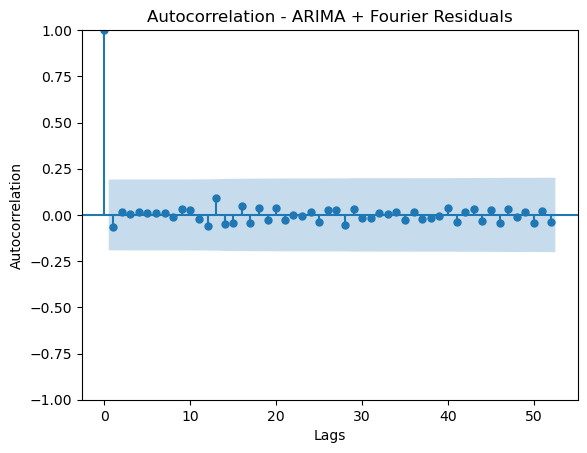

In [223]:
plot_acf(arima_res, lags=52)
plt.title("Autocorrelation - ARIMA + Fourier Residuals")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

This looks a lot like random noise, so that means we found a pretty strong fit

## Log Transform + SARIMA

Let's try applying a log transform to the data and then performing the autoarima search

In [23]:
y_tt = np.log(ord_weekly_tt)

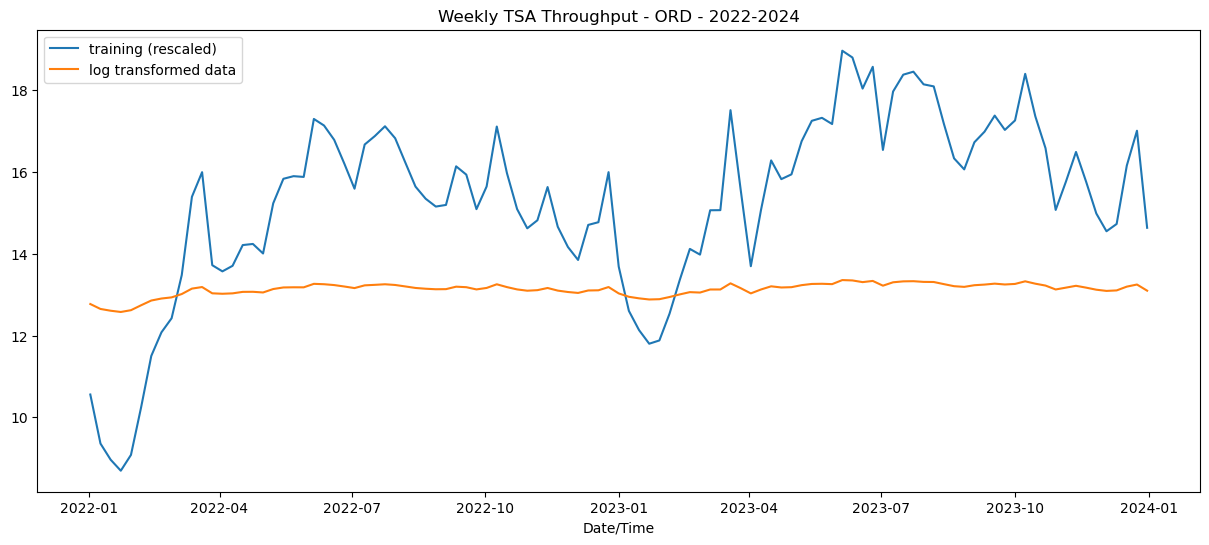

In [24]:
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_tt * 3e-5, label='training (rescaled)')
plt.plot(ord_weekly_tt.index, y_tt, label='log transformed data')
plt.title('Weekly TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.legend()
plt.show()

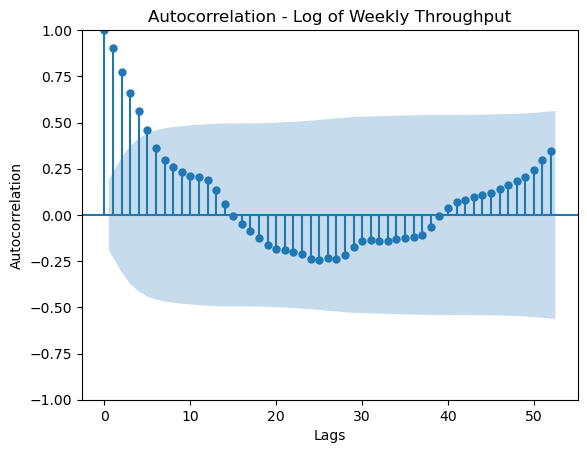

In [25]:
# Plot autocorrelation of log transformed data
plot_acf(y_tt, lags=52)
plt.title("Autocorrelation - Log of Weekly Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

In [28]:
arima_model = pm.auto_arima(
    y_tt,
    seasonal=True, m=52,
    max_d=1, max_D=1,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    stepwise=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=-279.841, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=inf, Time=9.99 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=inf, Time=8.01 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=-281.573, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=inf, Time=3.80 sec
 ARIMA(0,1,0)(0,0,1)[52] intercept   : AIC=inf, Time=13.91 sec
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=-315.946, Time=1.93 sec
 ARIMA(0,1,0)(2,0,1)[52] intercept   : AIC=-313.946, Time=27.65 sec
 ARIMA(0,1,0)(1,0,2)[52] intercept   : AIC=-313.946, Time=25.16 sec
 ARIMA(0,1,0)(0,0,2)[52] intercept   : AIC=inf, Time=59.48 sec
 ARIMA(0,1,0)(2,0,0)[52] intercept   : AIC=inf, Time=28.40 sec
 ARIMA(0,1,0)(2,0,2)[52] intercept   : AIC=-311.946, Time=36.83 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=-314.688, Time=4.75 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=-315.107, Time=4.62 sec
 ARIMA(1,1,1)(1,0,1)[52] intercept   : AIC=

In [31]:
print("ARIMA(0,1,0)(1,0,1)[52]: mse = ", mse(ord_weekly_val, np.exp(arima_model.predict(51))) / ord_weekly_val.mean())

ARIMA(0,1,0)(1,0,1)[52]: mse =  8837.371338328558


In [55]:
log_pred = arima_model.predict(51)
sigma2 = np.var(arima_model.resid(), ddof=1)  # variance of residuals on transformed scale
y_pred = np.exp(log_pred + 0.07 * sigma2)
print("ARIMA(0,1,0)(1,0,1)[52]: mse = ", mse(ord_weekly_val, y_pred) / ord_weekly_val.mean())

ARIMA(0,1,0)(1,0,1)[52]: mse =  2675.577660385502


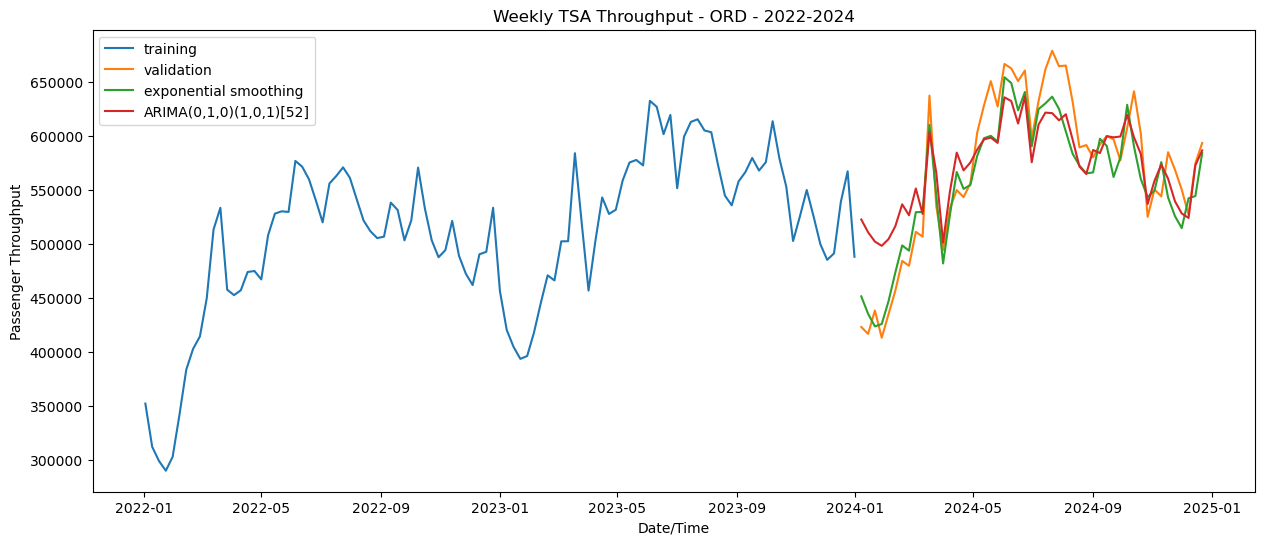

In [56]:
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_tt, label='training')
plt.plot(ord_weekly_val, label='validation')
plt.plot(ord_weekly_val.index, exps_model.forecast(51), label='exponential smoothing')
plt.plot(ord_weekly_val.index, y_pred, label='ARIMA(0,1,0)(1,0,1)[52]')
plt.title('Weekly TSA Throughput - ORD - 2022-2024')
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.legend()
plt.show()

In [7]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

In [8]:
from busy_airports.data_splits import make_rolling_splits